In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10,6)
OUTPUT_DIR = 'output_plots'
os.makedirs(OUTPUT_DIR, exist_ok=True)
DATA_PATH = 'data/user_behavior_dataset.csv'


In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(df.head(5))

Shape: (700, 11)
Columns: ['User ID', 'Device Model', 'Operating System', 'App Usage Time (min/day)', 'Screen On Time (hours/day)', 'Battery Drain (mAh/day)', 'Number of Apps Installed', 'Data Usage (MB/day)', 'Age', 'Gender', 'User Behavior Class']
   User ID    Device Model Operating System  App Usage Time (min/day)  \
0        1  Google Pixel 5          Android                       393   
1        2       OnePlus 9          Android                       268   
2        3    Xiaomi Mi 11          Android                       154   
3        4  Google Pixel 5          Android                       239   
4        5       iPhone 12              iOS                       187   

   Screen On Time (hours/day)  Battery Drain (mAh/day)  \
0                         6.4                     1872   
1                         4.7                     1331   
2                         4.0                      761   
3                         4.8                     1676   
4                    

In [3]:
# Приводим имена к удобному виду (snake_case)
df.columns = [c.strip() for c in df.columns]
col_map = {
    "User ID": "user_id",
    "Device Model": "device_model",
    "Operating System": "operating_system",
    "App Usage Time (min/day)": "app_usage_min_per_day",
    "Screen On Time (hours/day)": "screen_on_hours_per_day",
    "Battery Drain (mAh/day)": "battery_drain_mah_per_day",
    "Number of Apps Installed": "num_apps_installed",
    "Data Usage (MB/day)": "data_usage_mb_per_day",
    "Age": "age",
    "Gender": "gender",
    "User Behavior Class": "user_behavior_class"
}
# Если колонки в другом формате, попробуем сопоставить по нижнему регистру
lower_to_col = {c.lower(): c for c in df.columns}
rename_map = {}
for k, v in col_map.items():
    if k in df.columns:
        rename_map[k] = v
    elif k.lower() in lower_to_col:
        rename_map[lower_to_col[k.lower()]] = v
df.rename(columns=rename_map, inplace=True)
print("Переименованные колонки:", rename_map)
print("Текущие колонки:", list(df.columns))


Переименованные колонки: {'User ID': 'user_id', 'Device Model': 'device_model', 'Operating System': 'operating_system', 'App Usage Time (min/day)': 'app_usage_min_per_day', 'Screen On Time (hours/day)': 'screen_on_hours_per_day', 'Battery Drain (mAh/day)': 'battery_drain_mah_per_day', 'Number of Apps Installed': 'num_apps_installed', 'Data Usage (MB/day)': 'data_usage_mb_per_day', 'Age': 'age', 'Gender': 'gender', 'User Behavior Class': 'user_behavior_class'}
Текущие колонки: ['user_id', 'device_model', 'operating_system', 'app_usage_min_per_day', 'screen_on_hours_per_day', 'battery_drain_mah_per_day', 'num_apps_installed', 'data_usage_mb_per_day', 'age', 'gender', 'user_behavior_class']


In [4]:
print(f'Информация: \n {df.info()}')
print('-' * 45)
print(f'Пропуски по колонкам: \n {df.isna().sum()}')
print('-' * 45)
print('Статистика числовых колонок')
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_id                    700 non-null    int64  
 1   device_model               700 non-null    object 
 2   operating_system           700 non-null    object 
 3   app_usage_min_per_day      700 non-null    int64  
 4   screen_on_hours_per_day    700 non-null    float64
 5   battery_drain_mah_per_day  700 non-null    int64  
 6   num_apps_installed         700 non-null    int64  
 7   data_usage_mb_per_day      700 non-null    int64  
 8   age                        700 non-null    int64  
 9   gender                     700 non-null    object 
 10  user_behavior_class        700 non-null    int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 60.3+ KB
Информация: 
 None
---------------------------------------------
Пропуски по колонкам: 
 user_id        

In [5]:
df.dropna(how='all', inplace=True)
print(f"Дубликаты: \n {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

if 'operating_system' in df.columns:
    df['operating_system'] = df['operating_system'].astype(str).str.title()
    df.loc[df['operating_system'].str.contains('And', case=False, na=False), 'operating_system'] = 'Android'
    
    df.loc[df['operating_system'].str.contains('Ios', case=False, na=False), 'operating_system'] = 'iOS'
    
    df.loc[~df['operating_system'].isin(['Android', 'iOS']), 'operating_system'] = 'Other'
    

Дубликаты: 
 0


In [6]:
df['activity_level'] = pd.cut(
    df['app_usage_min_per_day'],
    bins=[-1, 199, 350, np.inf],
    labels=['Low', 'Medium', 'High']
)

bins = [0, 20, 30, 40, 50, 95]
labels = ['10-20', '21-30', '31-40', '41-50', '51+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

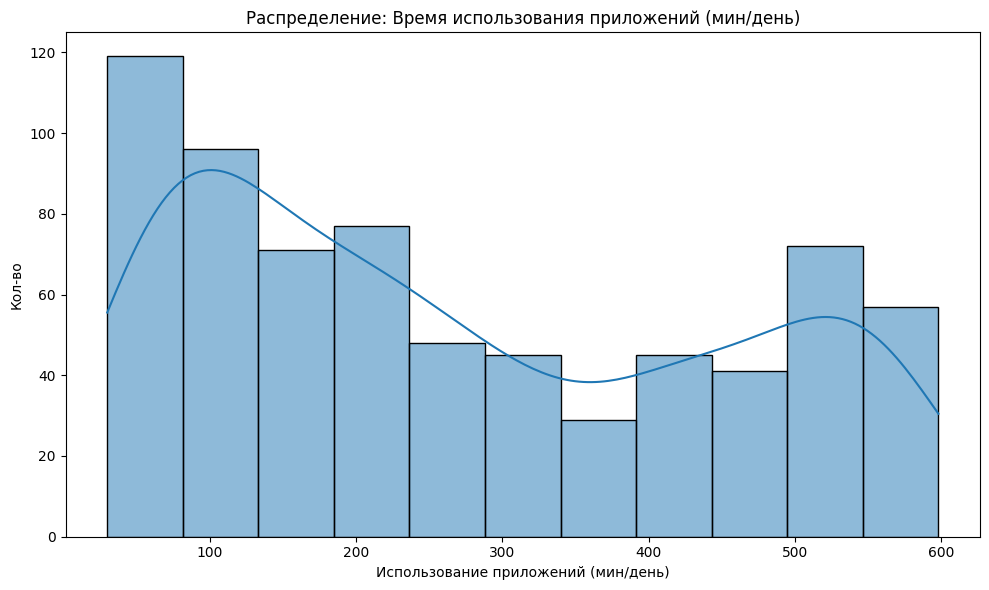

In [7]:
sns.histplot(df['app_usage_min_per_day'], kde=True)
plt.title('Распределение: Время использования приложений (мин/день)')
plt.xlabel('Использование приложений (мин/день)')
plt.ylabel('Кол-во')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'hist_app_usage_min_oer_day.png'))
plt.show()


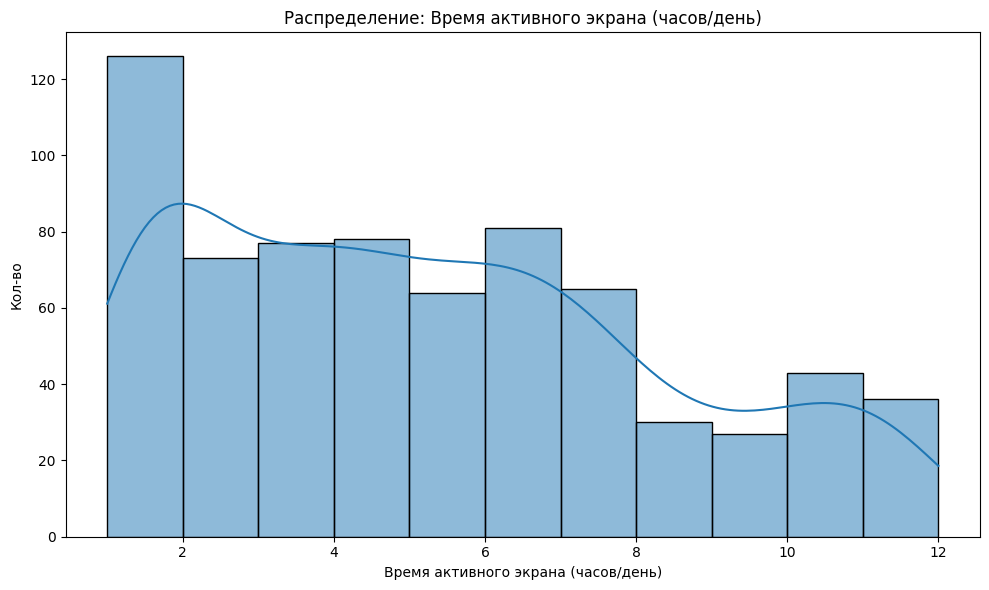

In [8]:
sns.histplot(df['screen_on_hours_per_day'], kde=True)
plt.title('Распределение: Время активного экрана (часов/день)')
plt.xlabel('Время активного экрана (часов/день)')
plt.ylabel('Кол-во')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'screen_on_hours_per_day.png'))
plt.show()

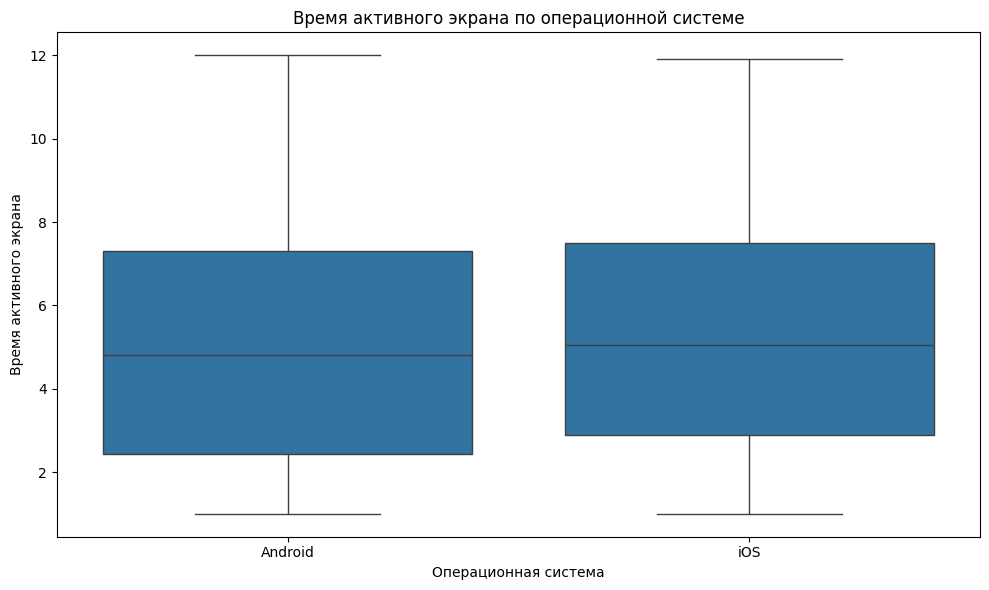

In [9]:
sns.boxplot(data=df, x='operating_system', y='screen_on_hours_per_day')
plt.title('Время активного экрана по операционной системе')
plt.xlabel('Операционная система')
plt.ylabel('Время активного экрана')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'box_screen_on_by_os.png'))
plt.show()

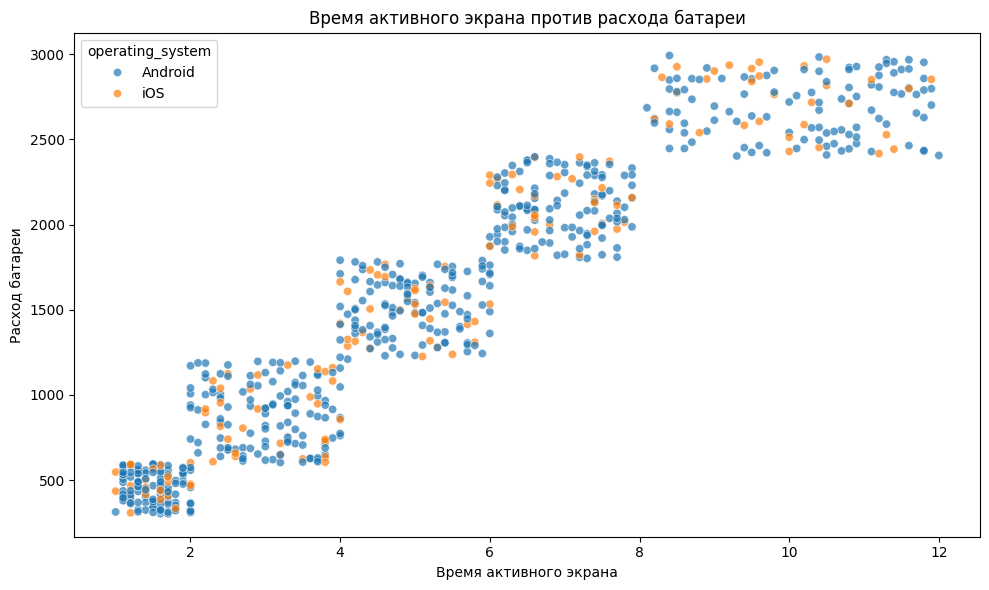

In [10]:
sns.scatterplot(data=df, x='screen_on_hours_per_day', y='battery_drain_mah_per_day', hue='operating_system', alpha=0.7)
plt.title('Время активного экрана против расхода батареи')
plt.xlabel('Время активного экрана')
plt.ylabel('Расход батареи')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'scatter_screen_vs_battery.png'))

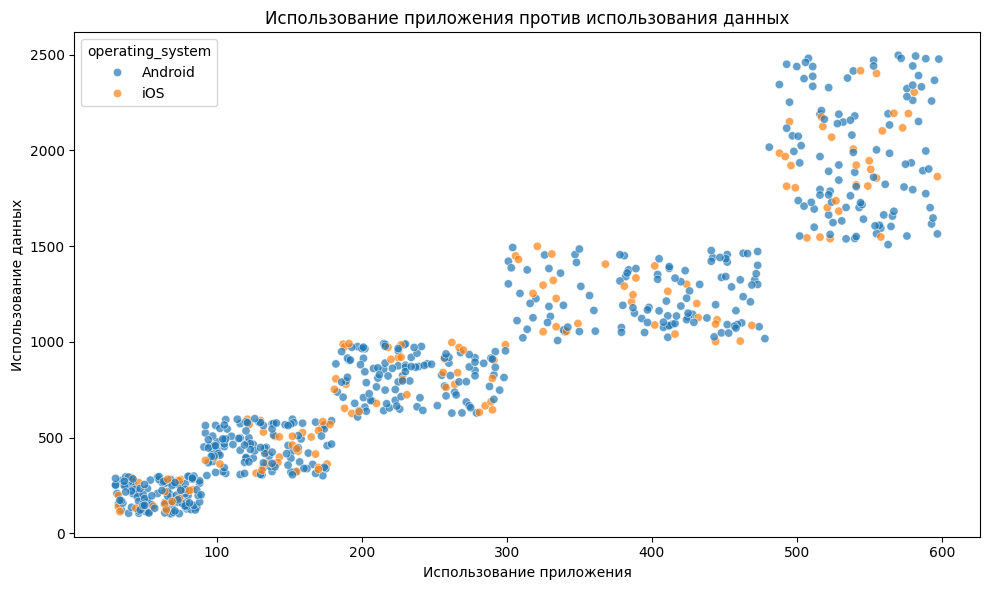

In [11]:
sns.scatterplot(data=df, x='app_usage_min_per_day', y='data_usage_mb_per_day', hue='operating_system', alpha=0.7)
plt.title('Использование приложения против использования данных')
plt.xlabel('Использование приложения')
plt.ylabel('Использование данных')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'scatter_usage_min_vs_data_usage.png'))

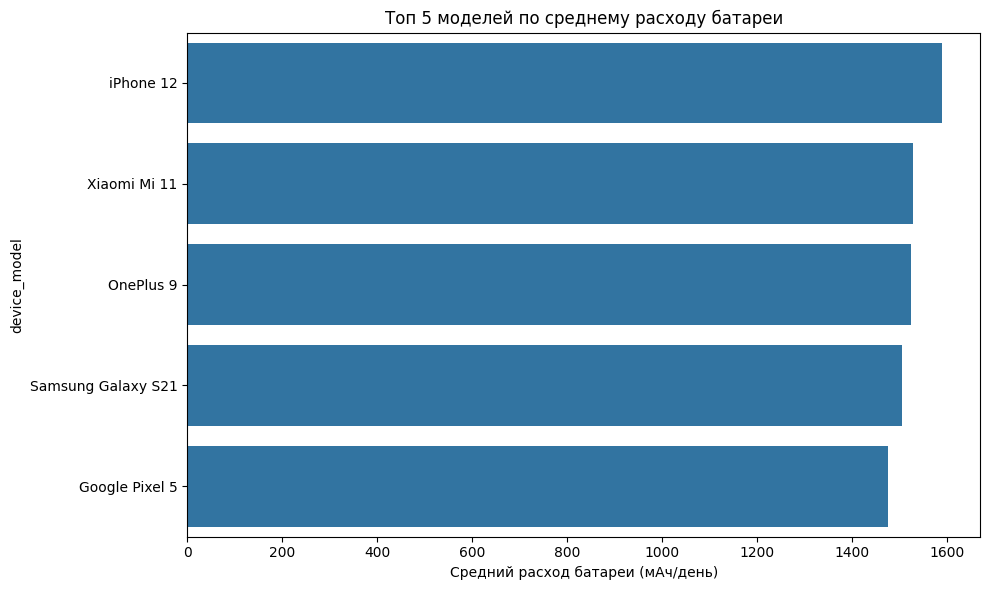

In [12]:
top5 = df.groupby('device_model')['battery_drain_mah_per_day'].mean().nlargest(5)
sns.barplot(x=top5.values, y=top5.index)
plt.title('Топ 5 моделей по среднему расходу батареи')
plt.xlabel('Средний расход батареи (мАч/день)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'top5_devices_battery_drain.png'))
plt.show()

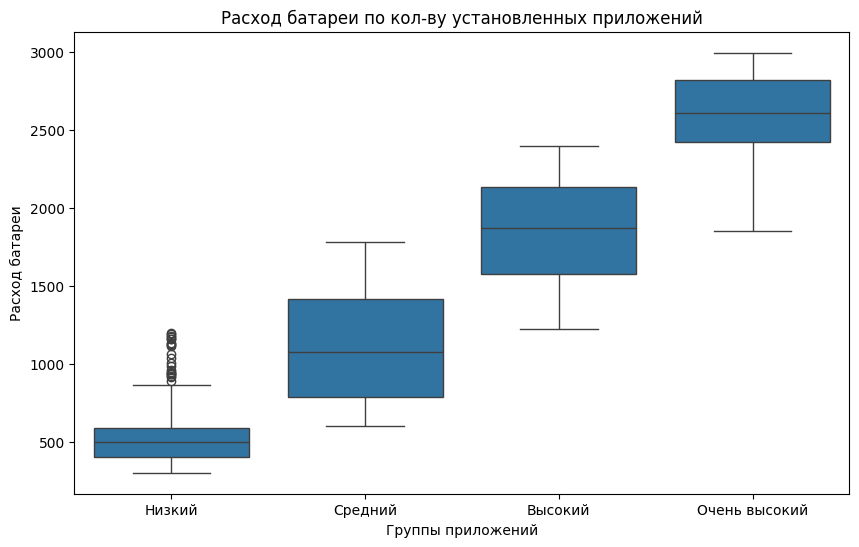

In [14]:
df['apps_bucket'] = pd.qcut(
    df['num_apps_installed'].rank(method='first'),
    q=4,
    labels=['Низкий', 'Средний', 'Высокий', 'Очень высокий']
)
sns.boxplot(data=df, x='apps_bucket', y='battery_drain_mah_per_day')
plt.title('Расход батареи по кол-ву установленных приложений')
plt.xlabel('Группы приложений')
plt.ylabel('Расход батареи')
plt.savefig(os.path.join(OUTPUT_DIR, 'box_battery_by_apps_bucket,png'))
plt.show()

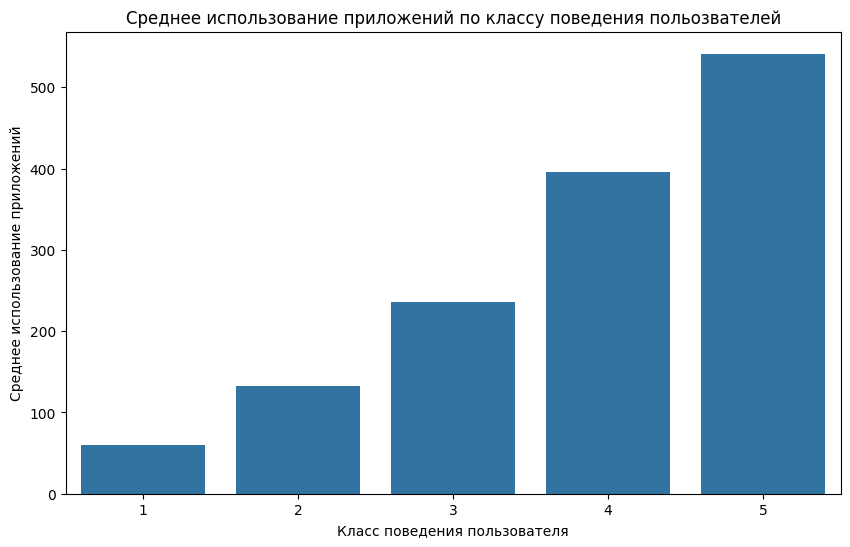

In [17]:
class_users = df.groupby('user_behavior_class').agg({
    'app_usage_min_per_day' : 'mean',
    'battery_drain_mah_per_day' : 'mean', 
    'data_usage_mb_per_day' : 'mean',
    'num_apps_installed' : 'mean',
}).reset_index().sort_values('app_usage_min_per_day', ascending=False)

sns.barplot(data=class_users, x='user_behavior_class', y='app_usage_min_per_day')
plt.title('Среднее использование приложений по классу поведения польозвателей')
plt.xlabel('Класс поведения пользователя')
plt.ylabel('Среднее использование приложений')
plt.savefig(os.path.join(OUTPUT_DIR, 'bar_app_usage_by_bahavior_class.png'))
plt.show()

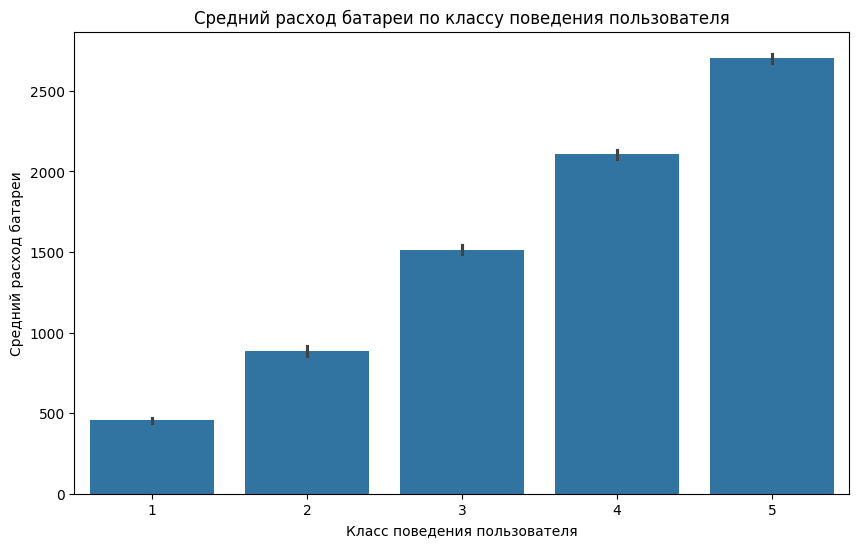

In [18]:
sns.barplot(x='user_behavior_class', y='battery_drain_mah_per_day', data=df)
plt.title('Средний расход батареи по классу поведения пользователя')
plt.xlabel('Класс поведения пользователя')
plt.ylabel('Средний расход батареи')
plt.savefig(os.path.join(OUTPUT_DIR, 'bar_battery_by_bahavior_class.png'))
plt.show()
